# Telecom Customer Churn — Data Cleaning & EDA

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## Load raw data

In [38]:
df_raw = pd.read_csv("E://Sakthi//prasanth//telecom-churn-ai//data//raw//WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 2. Data Quality Audit (before touching anything)



### Standard missing values (`.isnull()`)

In [10]:
missing = df_raw.isnull().sum()
missing[missing > 0]


Series([], dtype: int64)

###  The hidden `TotalCharges` problem

In [11]:
blank_mask = df_raw["TotalCharges"].str.strip() == ""
print("Blank TotalCharges rows:", blank_mask.sum())
df_raw.loc[blank_mask, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

Blank TotalCharges rows: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


### Duplicates

In [12]:
print("Duplicate customerIDs:", df_raw["customerID"].duplicated().sum())
print("Full row duplicates:", df_raw.duplicated().sum())


Duplicate customerIDs: 0
Full row duplicates: 0


###  Outlier check (IQR) on numeric columns

In [13]:
def count_iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((series < lower) | (series > upper)).sum())

numeric_view = df_raw.copy()
numeric_view["TotalCharges"] = pd.to_numeric(numeric_view["TotalCharges"], errors="coerce")

for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    print(col, "-> outliers found:", count_iqr_outliers(numeric_view[col].dropna()))


tenure -> outliers found: 0
MonthlyCharges -> outliers found: 0
TotalCharges -> outliers found: 0


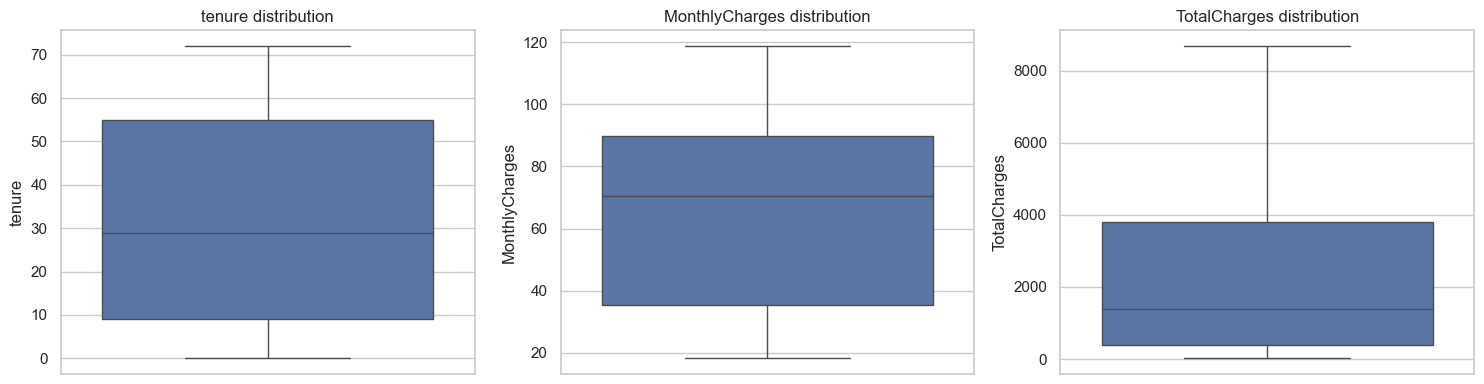

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.boxplot(y=numeric_view[col].dropna(), ax=ax, color="#4C72B0")
    ax.set_title(f"{col} distribution")
plt.tight_layout()
plt.show()


###  Inconsistent categorical values

In [15]:
for col in ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
            "TechSupport", "StreamingTV", "StreamingMovies", "MultipleLines"]:
    print(col, "->", df_raw[col].unique())


OnlineSecurity -> ['No' 'Yes' 'No internet service']
OnlineBackup -> ['Yes' 'No' 'No internet service']
DeviceProtection -> ['No' 'Yes' 'No internet service']
TechSupport -> ['No' 'Yes' 'No internet service']
StreamingTV -> ['No' 'Yes' 'No internet service']
StreamingMovies -> ['No' 'Yes' 'No internet service']
MultipleLines -> ['No phone service' 'No' 'Yes']


### Class balance (churn vs no churn)

C:\Users\L E N O V O\AppData\Local\Temp\ipykernel_17824\1112284244.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_counts.index, y=churn_counts.values, palette=["#4C72B0", "#C44E52"], ax=ax)


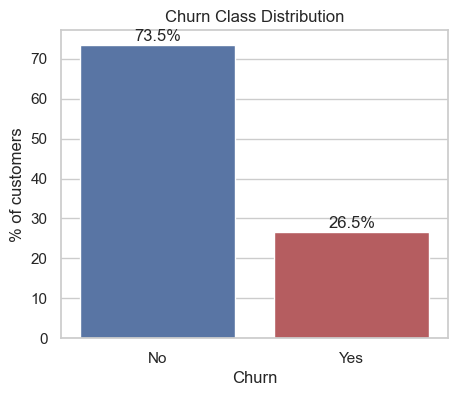

In [16]:
churn_counts = df_raw["Churn"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=churn_counts.index, y=churn_counts.values, palette=["#4C72B0", "#C44E52"], ax=ax)
ax.set_ylabel("% of customers")
ax.set_title("Churn Class Distribution")
for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.show()


## 3. Cleaning

### Fix `TotalCharges`: convert to a number, fill the 11 blanks with 0.0

In [17]:
df = df_raw.copy()

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

blank_mask = df["TotalCharges"].isna()
print("Rows to fix:", blank_mask.sum())

# Safety check: confirm our assumption that all blanks are tenure == 0 still holds
assert (df.loc[blank_mask, "tenure"] == 0).all(), "Found a blank TotalCharges with tenure != 0 -- investigate before imputing with 0!"

df.loc[blank_mask, "TotalCharges"] = 0.0
print("Remaining missing TotalCharges:", df["TotalCharges"].isna().sum())


Rows to fix: 11
Remaining missing TotalCharges: 0


### Remove exact duplicate rows (defensive — we already confirmed there are none, but this makes the notebook safe to re-run on a refreshed dataset)

In [18]:
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")


Removed 0 duplicate rows


### Collapse redundant "No internet/phone service" categories into "No" 

In [19]:
cols_to_fix = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
               "TechSupport", "StreamingTV", "StreamingMovies", "MultipleLines"]

for col in cols_to_fix:
    df[col] = df[col].replace({"No internet service": "No", "No phone service": "No"})

# confirm the fix worked
for col in cols_to_fix:
    print(col, "->", df[col].unique())


OnlineSecurity -> ['No' 'Yes']
OnlineBackup -> ['Yes' 'No']
DeviceProtection -> ['No' 'Yes']
TechSupport -> ['No' 'Yes']
StreamingTV -> ['No' 'Yes']
StreamingMovies -> ['No' 'Yes']
MultipleLines -> ['No' 'Yes']


###  Basic range validation (defensive — this dataset already passes cleanly)

In [20]:
before = len(df)
df = df[(df["tenure"] >= 0) & (df["MonthlyCharges"] > 0)]
print(f"Removed {before - len(df)} rows with invalid ranges")

Removed 0 rows with invalid ranges


###  Convert the target column to a clean binary label (`Yes`/`No` → `1`/`0`)

Machine learning models need numbers, not text, for the target column.


In [21]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0}).astype(int)
df["Churn"].value_counts()


Churn
0    5174
1    1869
Name: count, dtype: int64

### 3.6 Final check + save the cleaned dataset

In [22]:
df = df.reset_index(drop=True)
print("Final cleaned shape:", df.shape)
df.head()


Final cleaned shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [28]:
df.to_csv("E://Sakthi//prasanth//telecom-churn-ai//data//processed//churn_cleaned_v1.csv", index=False)

print("Saved to telecom-churn-ai/data/processed/churn_cleaned_v1.csv")


Saved to telecom-churn-ai/data/processed/churn_cleaned_v1.csv


## 4. Exploratory Data Analysis

Now that the data is clean, we look at what actually drives churn. These are the
signals we expect to see reflected later in the model's explanations.


### Churn by contract type

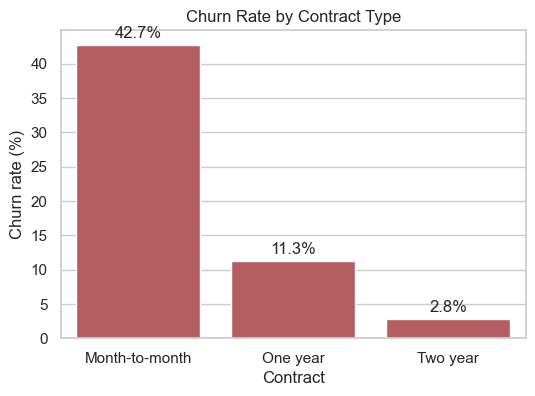

In [29]:
contract_churn = df.groupby("Contract")["Churn"].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=contract_churn.index, y=contract_churn.values, color="#C44E52", ax=ax)
ax.set_ylabel("Churn rate (%)")
ax.set_title("Churn Rate by Contract Type")
for i, v in enumerate(contract_churn.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.show()


**Finding:** Month-to-month customers churn at 42.7% vs just 2.8% for two-year contracts — by far the strongest single predictor in the dataset.

### Churn by tenure

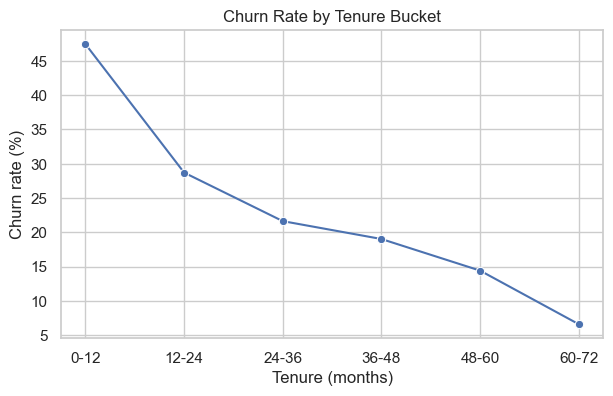

In [30]:
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ["0-12", "12-24", "24-36", "36-48", "48-60", "60-72"]
df["tenure_bucket"] = pd.cut(df["tenure"], bins=bins, labels=labels, include_lowest=True)
tenure_churn = df.groupby("tenure_bucket", observed=True)["Churn"].mean() * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.lineplot(x=tenure_churn.index, y=tenure_churn.values, marker="o", ax=ax, color="#4C72B0")
ax.set_ylabel("Churn rate (%)")
ax.set_xlabel("Tenure (months)")
ax.set_title("Churn Rate by Tenure Bucket")
plt.show()


###  Churn by internet service type

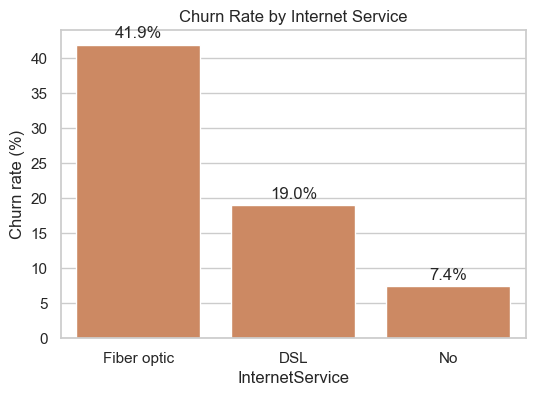

In [31]:
internet_churn = df.groupby("InternetService")["Churn"].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=internet_churn.index, y=internet_churn.values, color="#DD8452", ax=ax)
ax.set_ylabel("Churn rate (%)")
ax.set_title("Churn Rate by Internet Service")
for i, v in enumerate(internet_churn.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.show()


### Churn by payment method

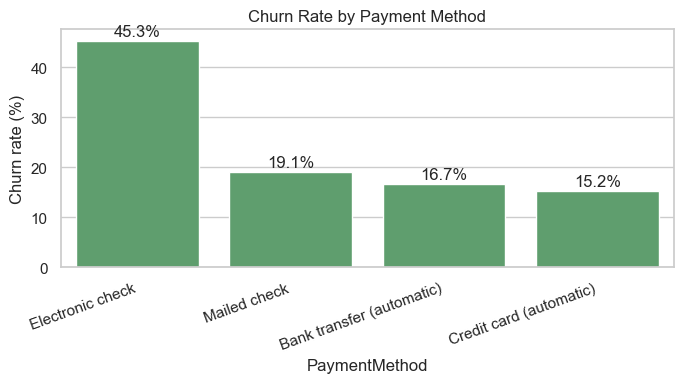

In [32]:
payment_churn = df.groupby("PaymentMethod")["Churn"].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=payment_churn.index, y=payment_churn.values, color="#55A868", ax=ax)
ax.set_ylabel("Churn rate (%)")
ax.set_title("Churn Rate by Payment Method")
plt.xticks(rotation=20, ha="right")
for i, v in enumerate(payment_churn.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()


### Monthly charges: churned vs retained

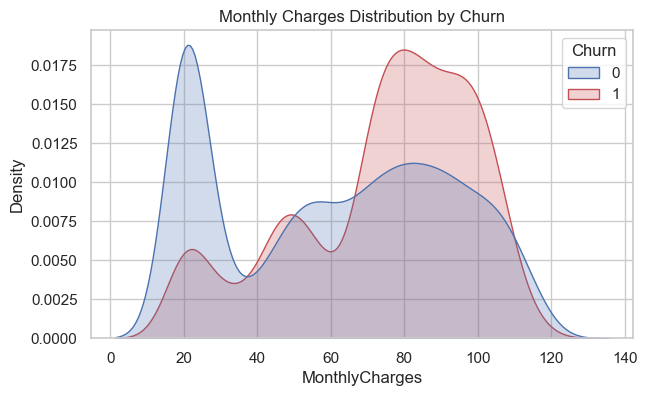

Churn
0    61.27
1    74.44
Name: MonthlyCharges, dtype: float64


In [33]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", fill=True, common_norm=False,
            palette={0: "#4C72B0", 1: "#C44E52"}, ax=ax)
ax.set_title("Monthly Charges Distribution by Churn")
plt.show()

print(df.groupby("Churn")["MonthlyCharges"].mean().round(2))


### Senior citizens (a fairness-relevant attribute to keep in mind later)

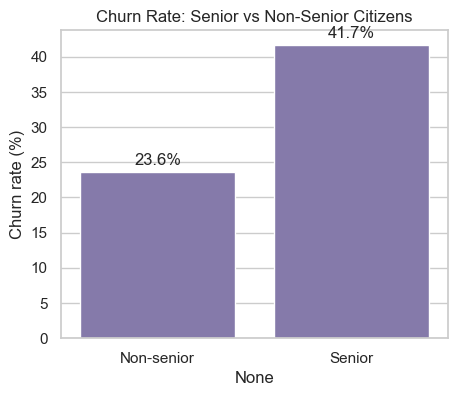

In [34]:
senior_churn = df.groupby("SeniorCitizen")["Churn"].mean() * 100
senior_churn.index = ["Non-senior", "Senior"]

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=senior_churn.index, y=senior_churn.values, color="#8172B2", ax=ax)
ax.set_ylabel("Churn rate (%)")
ax.set_title("Churn Rate: Senior vs Non-Senior Citizens")
for i, v in enumerate(senior_churn.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.show()


### Correlation among numeric features

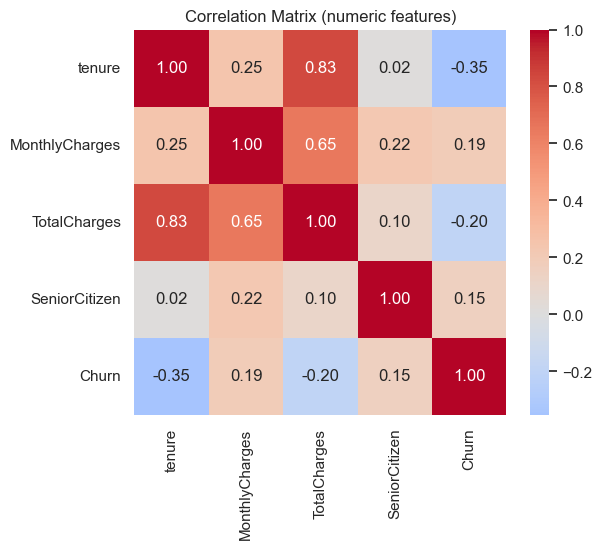

In [35]:
corr_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=ax)
ax.set_title("Correlation Matrix (numeric features)")
plt.show()


## 5. Summary

**Data quality issues found and fixed:**
- `TotalCharges` stored as text with 11 blank values (all `tenure == 0`, new customers) → converted to numeric, filled with `0.0`
- Redundant `"No internet/phone service"` categories collapsed into `"No"` across 7 columns
- Confirmed: 0 duplicate customers, 0 duplicate rows, 0 invalid ranges
- Confirmed: 0 statistical outliers by IQR — kept all rows as-is

**Top churn drivers found in EDA:**
| Driver | Finding |
|---|---|
| Contract type | Month-to-month churns 15x more than two-year contracts |
| Tenure | Churn falls from 47.4% (new customers) to 6.6% (5+ years) |
| Internet service | Fiber optic churns 2x more than DSL |
| Payment method | Electronic check churns 2-3x more than automatic payments |
| Monthly charges | Churners pay more on average |
| Senior citizen | Churn nearly doubles — flagged for later fairness audit |

**Final output of this notebook:** `data/processed/churn_cleaned_v1.csv` — the clean,
ready-to-use dataset that the next phase (feature engineering + model training) will
build on.
